<a href="https://colab.research.google.com/github/banuben/computer_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install torch

In [3]:
import torch

In [4]:
print(torch.__version__)

2.11.0+cu128


In [5]:
print('CUDA available:', torch.cuda.is_available())

CUDA available: True


In [14]:
scalar = torch.tensor(5)  #0D
print('scalar', scalar)
print(scalar.item())
print(scalar.ndim)
print(scalar.shape)
print('Size:', scalar.size())

scalar tensor(5)
5
0
torch.Size([])
Size: torch.Size([])


In [13]:
vector = torch.tensor([1, 2, 3])  #1D
print('vector', vector)
print(vector.ndim)
print(vector.shape)
print('Size:', vector.size())

vector tensor([1, 2, 3])
1
torch.Size([3])
Size: torch.Size([3])


In [15]:
MATRIX = torch.tensor([[1, 2, 3], [4, 5, 6]])  #2D
print('matrix', MATRIX)
print(MATRIX.ndim)
print(MATRIX.shape)
print('Size:', MATRIX.size())

matrix tensor([[1, 2, 3],
        [4, 5, 6]])
2
torch.Size([2, 3])
Size: torch.Size([2, 3])


In [19]:
tensor3d = torch.stack([MATRIX, MATRIX + 10]) #3D
print('tensor3d:', tensor3d)
print('Dimension of tensor3d:', tensor3d.ndim)
print('Shape of tensor3d:',tensor3d.shape)    # [2,2,3] | 2 matrices => channels | 2 rows in each matrix | 3 columns in each matrix (height, width) [C, H, W]
print('Size:', tensor3d.size())

tensor3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])
Dimension of tensor3d: 3
Shape of tensor3d: torch.Size([2, 2, 3])
Size: torch.Size([2, 2, 3])


In [24]:
random_numbers = torch.rand(2, 3) # 0~1
print('random_numbers:', random_numbers)
print('Dimension of random_numbers:', random_numbers.ndim)
print('Shape of random_numbers:', random_numbers.shape)
print('Size:', random_numbers.size())
print('Random numbers dtype:', random_numbers.dtype)
print('Random numbers device:', random_numbers.device)

random_numbers: tensor([[0.4059, 0.4858, 0.5279],
        [0.3518, 0.4448, 0.5436]])
Dimension of random_numbers: 2
Shape of random_numbers: torch.Size([2, 3])
Size: torch.Size([2, 3])
Random numbers dtype: torch.float32
Random numbers device: cpu


In [21]:
print('Zeros', torch.zeros(3, 3))

Zeros tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [22]:
print('Ones:', torch.ones(2, 4))

Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [25]:
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])
print('x + y:', x + y)
print('x - y:', x - y)
print('x * y:', x * y)
print('x / y:', x / y)
print('x @ y:', x @ y) # Matrix multiplication(dot product)
# =
print('x @ y:', torch.matmul(x, y))



x + y: tensor([[ 6,  8],
        [10, 12]])
x - y: tensor([[-4, -4],
        [-4, -4]])
x * y: tensor([[ 5, 12],
        [21, 32]])
x / y: tensor([[0.2000, 0.3333],
        [0.4286, 0.5000]])
x @ y: tensor([[19, 22],
        [43, 50]])


# [1, 2] * [5, 7] = 15+27 = 5+14 =19
# [1, 2] * [6, 8] = 16+28 = 6+16 =22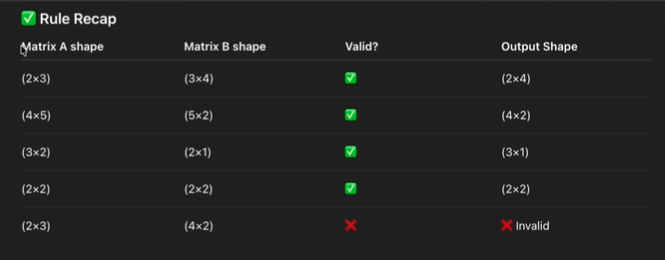

In [28]:
# Import PyTorch and matplotlib
import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cu128'

In [27]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [26]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
# without unsqueeze, errors will happen later on
# (shapes within linear layers)

y = weight * X + bias

# Split data
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

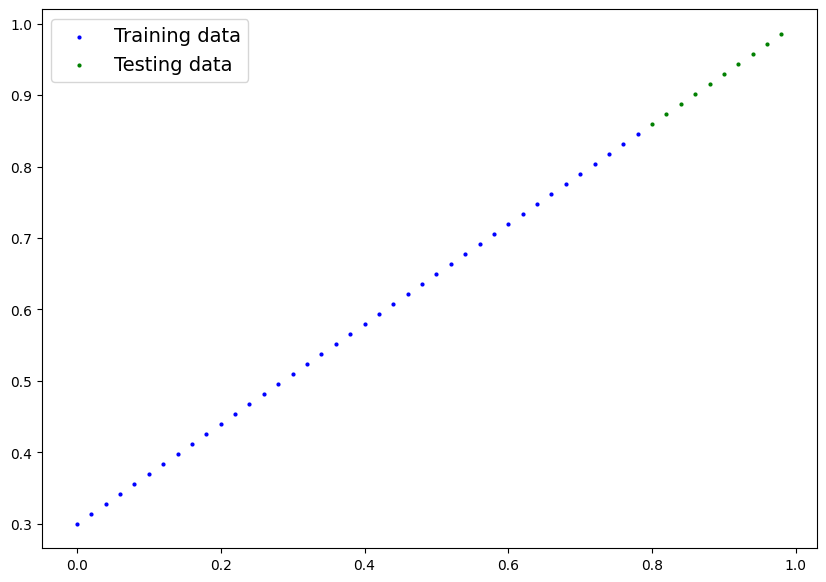

In [45]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data.cpu().numpy(), train_labels.cpu().numpy(),
                c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data.cpu().numpy(), test_labels.cpu().numpy(),
                c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data.cpu().numpy(), predictions.cpu().numpy(),
                    c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})


plot_predictions()

# Model yaratish

In [30]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):

    def __init__(self):
        super().__init__()

        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(
            in_features=1,   # weight
            out_features=1   # Linear => y = wx + b
        )

    # Define the forward computation
    # (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Set the manual seed when creating the model
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

# Loss Function va Optimizer

In [35]:
# Create loss function
loss_fn = nn.L1Loss()     # Loss Function | MAE -> Mean Absolute Error

# Create optimizer
optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.01
)

# Trainingdan oldingi prediction

Text(0.5, 1.0, 'Predictions before training (red = random guesses)')

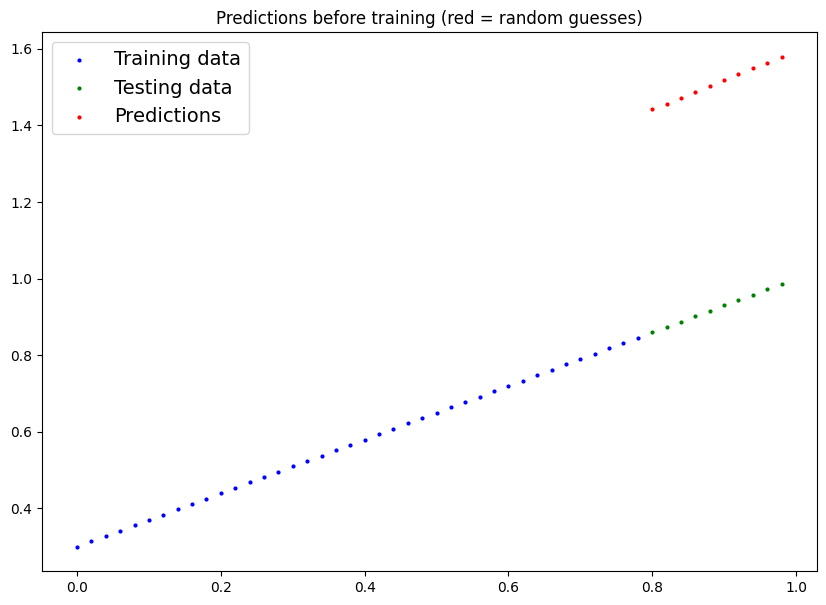

In [32]:
# See model's untrained predictions (on test set)
model_1.eval()

with torch.inference_mode():
    y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)

plt.title("Predictions before training (red = random guesses)")

In [38]:
# Set the number of epochs
epochs = 1000

# Put data on the available device
# Without this, error could happen
# (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

model_1.to(device)

for epoch in range(epochs):

    ## Training
    model_1.train()  # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ## Testing
    model_1.eval()  # put the model in evaluation mode for testing (inference)

    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    # Print out what's happening
    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss} | "
            f"Test loss: {test_loss}"
        )

Epoch: 0 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 100 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 200 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 300 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 400 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 500 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 600 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 700 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 800 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 900 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882


In [40]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds



tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

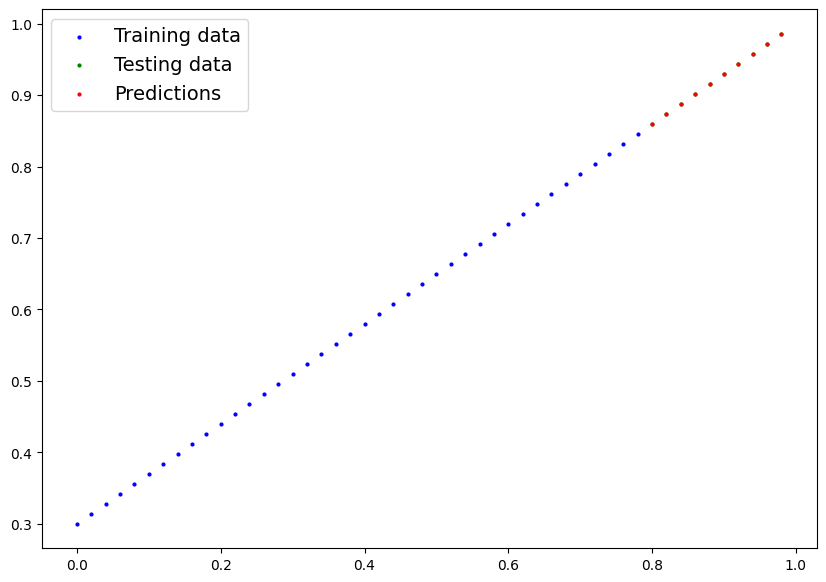

In [46]:
# Plot predictions vs truth
plot_predictions(predictions=y_preds)

In [47]:
torch.save(model_1.state_dict(), "trained_model.pth")

In [48]:
loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load("trained_model.pth"))

loaded_model.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)